In [1]:
# 导入必要的库
import torch  # PyTorch 深度学习框架
import numpy as np  # 数值计算库
import matplotlib.pyplot as plt  # 绘图库
from torch import nn  # PyTorch 神经网络模块
import torchvision as TV  # 计算机视觉工具库

In [2]:
# 加载 MNIST 数据集
# 训练集：60000 张手写数字图像
mnist_data = TV.datasets.MNIST("MNIST/", train=True, transform=None, \
                               target_transform=None, download=True) 

# 测试集：10000 张手写数字图像
mnist_test = TV.datasets.MNIST("MNIST/", train=False, transform=None, \
                               target_transform=None, download=True)

In [3]:
def add_spots(img:torch.Tensor, noise:int=20, std:int=5, val:float=1)->torch.Tensor:
    mask = torch.zeros(img.shape)
    N = int(noise + std * abs(np.random.randn()))
    if N < 0: 
        raise ValueError("noise cant be smaller than 0")
    
    ids = np.random.randint(0, np.prod(img.shape), size=N)
    mask.view(-1)[ids] = val
    return torch.clamp(img + mask, 0, 1)

def prepare_images(imgs:torch.Tensor,maxtrans:int=6,rot:int=5,noise:int=20)->torch.Tensor:
    out = torch.zeros(imgs.shape)

    for i in range(imgs.shape[0]):
        img = imgs[i].unsqueeze(dim=0)
        img = TV.transforms.functional.to_pil_image(img)

        xtrans, ytrans = np.random.randint(-maxtrans, maxtrans, 2)
        rand_rot = np.random.randint(-rot, rot) if rot > 0 else 0
        img = TV.transforms.functional.affine(img,rand_rot,(xtrans,ytrans),1,0)

        img = TV.transforms.functional.to_tensor(img).squeeze()

        if noise > 0: img = add_spots(img,noise=noise)
        maxval = img.view(-1).max()

        if maxval > 0: img /= maxval

        out[i] = img

    return out

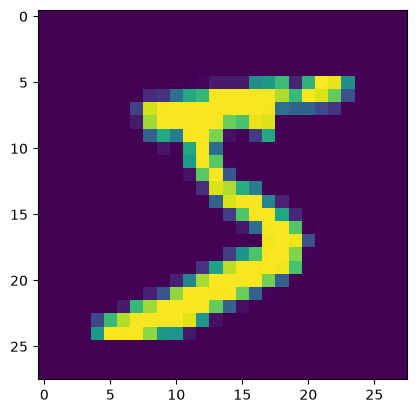

In [4]:
img,label  = mnist_data[0]

plt.imshow(img)

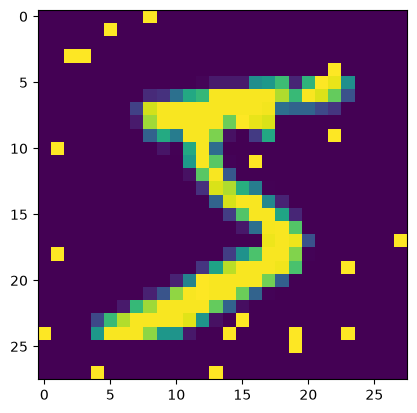

In [5]:
img = TV.transforms.functional.to_tensor(img)
img = add_spots(img)
img = TV.transforms.functional.to_pil_image(img)
plt.imshow(img)

In [6]:
class RelationalModule(torch.nn.Module):
    def __init__(self):
        super().__init__()
        # Defines the number of channels 
        # for each convolutional layer
        self.ch_in = 1
        self.conv1_ch = 16
        self.conv2_ch = 20
        self.conv3_ch = 24
        self.conv4_ch = 30
        # self.H and self.W are the height and width 
        # of the input image, respectively.
        self.H = 28
        self.W = 28
        # The dimension of the nodes 
        # after passing through the relational module
        self.node_size = 36
        self.lin_hid = 100
        self.out_dim = 10
        self.sp_coord_dim = 2
        # The number of objects or nodes, which is just 
        # the number of pixels after passing through the convolutions
        self.N = int(16**2)

        self.conv1 = nn.Conv2d(self.ch_in,self.conv1_ch,kernel_size=(4,4))
        self.conv2 = nn.Conv2d(self.conv1_ch,self.conv2_ch,kernel_size=(4,4))
        self.conv3 = nn.Conv2d(self.conv2_ch,self.conv3_ch,kernel_size=(4,4))
        self.conv4 = nn.Conv2d(self.conv3_ch,self.conv4_ch,kernel_size=(4,4))

        self.proj_shape = (self.conv4_ch+self.sp_coord_dim,self.node_size)
        self.k_proj = nn.Linear(*self.proj_shape)
        self.q_proj = nn.Linear(*self.proj_shape)
        self.v_proj = nn.Linear(*self.proj_shape)

        self.norm_shape = (self.N,self.node_size)
        self.k_norm = nn.LayerNorm(self.norm_shape, elementwise_affine=True)
        self.q_norm = nn.LayerNorm(self.norm_shape, elementwise_affine=True)
        self.v_norm = nn.LayerNorm(self.norm_shape, elementwise_affine=True)

        self.linear1 = nn.Linear(self.node_size, self.node_size)
        self.norm1 = nn.LayerNorm([self.N,self.node_size], elementwise_affine=False)
        self.linear2 = nn.Linear(self.node_size, self.out_dim)
        
    def forward(self,x):
        N, Cin, H, W = x.shape
        x = self.conv1(x)
        x = torch.relu(x)
        x = self.conv2(x)
        x = x.squeeze()
        x = torch.relu(x)
        x = self.conv3(x)
        x = torch.relu(x)
        x = self.conv4(x)
        x = torch.relu(x)

        _,_,cH,cW = x.shape

        xcoords = torch.arange(cW).repeat(cH,1).float() / cW
        ycoords = torch.arange(cH).repeat(cW,1).transpose(1,0).float() / cH
        spatial_coords = torch.stack([xcoords,ycoords],dim=0)
        spatial_coords = spatial_coords.unsqueeze(dim=0)
        spatial_coords = spatial_coords.repeat(N,1,1,1)
        x = torch.cat([x,spatial_coords], dim=1)

        x = x.permute(0,2,3,1)
        x = x.flatten(1,2)

        K = self.k_proj(x)
        K = self.k_norm(K)

        Q = self.q_proj(x)
        Q = self.q_norm(Q)

        V = self.v_proj(x)
        V = self.v_norm(V)

        A = torch.einsum('bfe,bge->bfg',Q,K)
        A = A / np.sqrt(self.node_size)
        A = torch.nn.functional.softmax(A,dim=2)

        with torch.no_grad():
            self.att_map = A.clone()

        E = torch.einsum('bfc,bcd->bfd',A,V)
        E = self.linear1(E)
        E = torch.relu(E)
        E = self.norm1(E)
        E = E.max(dim=1)[0]
        y = self.linear2(E)
        y = torch.nn.functional.log_softmax(y,dim=1)
        return y

        

In [7]:
agent = RelationalModule()
epochs = 2000
batch_size = 300
lr = 1e-3
opt = torch.optim.Adam(params=agent.parameters(),lr=lr)
lossfn = nn.NLLLoss()
losses = []
accuracy = []
for i in range(epochs):
    opt.zero_grad()
    batch_ids = np.random.randint(0, 60000, size=batch_size)
    xt = mnist_data.data[batch_ids].detach()
    xt = prepare_images(xt,rot=30).unsqueeze(dim=1)
    yt = mnist_data.targets[batch_ids].detach()
    pred = agent(xt)
    pred_labels = torch.argmax(pred,dim=1)

    acc_ = 100 * (pred_labels == yt).sum() / batch_size
    accuracy.append(acc_)
    correct = torch.zeros(batch_size,10)
    rows = torch.arange(batch_size).long()
    correct[rows,yt.detach().long()] = 1
    loss = lossfn(pred,yt)
    losses.append(loss.detach())
    loss.backward()
    opt.step()


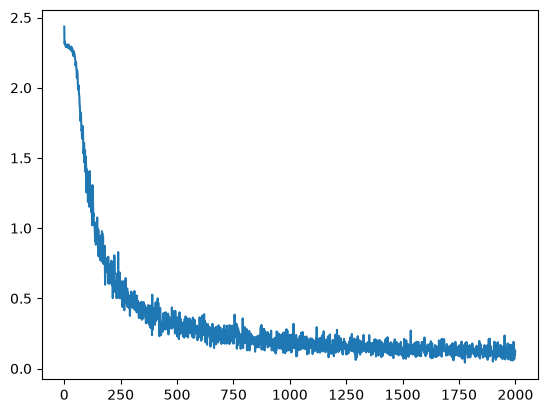

In [8]:
plt.plot(losses)

In [9]:
print(losses)

[tensor(2.4359), tensor(2.3138), tensor(2.3151), tensor(2.3280), tensor(2.3074), tensor(2.3057), tensor(2.3081), tensor(2.2908), tensor(2.3011), tensor(2.2947), tensor(2.3050), tensor(2.2898), tensor(2.3048), tensor(2.3084), tensor(2.2994), tensor(2.2959), tensor(2.2950), tensor(2.2836), tensor(2.2975), tensor(2.3078), tensor(2.2927), tensor(2.2971), tensor(2.2854), tensor(2.2809), tensor(2.2882), tensor(2.2737), tensor(2.2788), tensor(2.2892), tensor(2.2755), tensor(2.2722), tensor(2.2850), tensor(2.2939), tensor(2.2699), tensor(2.2647), tensor(2.2634), tensor(2.2805), tensor(2.2753), tensor(2.2494), tensor(2.2442), tensor(2.2336), tensor(2.2500), tensor(2.2251), tensor(2.2617), tensor(2.2317), tensor(2.2468), tensor(2.2423), tensor(2.2308), tensor(2.2170), tensor(2.2124), tensor(2.1952), tensor(2.1583), tensor(2.1727), tensor(2.1844), tensor(2.1522), tensor(2.1323), tensor(2.1105), tensor(2.0695), tensor(2.1262), tensor(2.1022), tensor(2.0961), tensor(2.0343), tensor(1.9874), tensor(

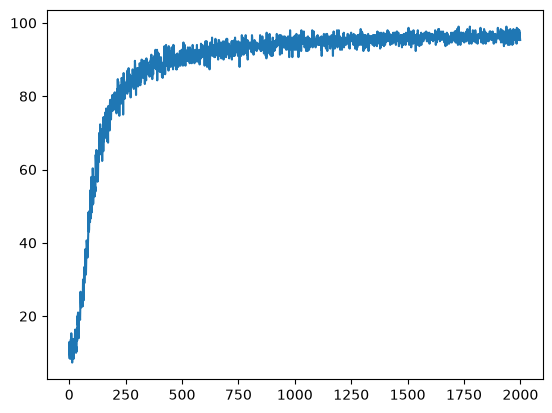

In [10]:
plt.plot(accuracy)

In [11]:
print(accuracy[-1])

tensor(95.3333)


In [12]:
def test_acc(model,batch_size=500):
    acc = 0.
    batch_ids = np.random.randint(0,10000,size=batch_size)
    xt = mnist_test.data[batch_ids].detach()
    xt = prepare_images(xt,maxtrans=6,rot=30,noise=10).unsqueeze(dim=1)
    yt = mnist_test.targets[batch_ids].detach()
    preds = model(xt)
    pred_ind = torch.argmax(preds.detach(),dim=1)
    acc = (pred_ind == yt).sum().float() / batch_size
    return acc, xt, yt

In [13]:
acc2, xt2, yt2 = test_acc(agent)

In [14]:
print(acc2)

tensor(0.9860)


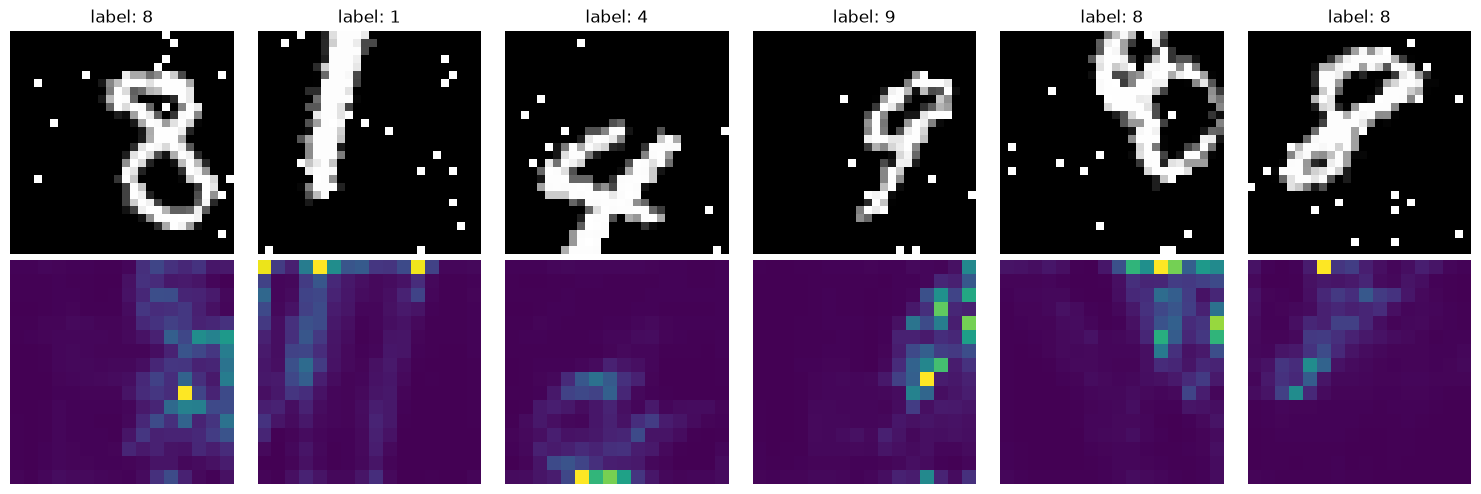

In [15]:
n = 6  # 显示 6 个样本
fig, axes = plt.subplots(2, n, figsize=(2.5*n, 5))
for i in range(n):
    orig = xt2[i].squeeze().detach().numpy()
    att = agent.att_map[i].max(dim=0)[0].view(16, 16).detach().numpy()
    axes[0, i].imshow(orig, cmap='gray'); axes[0, i].axis('off')
    axes[0, i].set_title(f"label: {yt2[i].item()}")
    axes[1, i].imshow(att); axes[1, i].axis('off')
axes[0, 0].set_ylabel("Original", fontsize=12)
axes[1, 0].set_ylabel("Attention", fontsize=12)
plt.tight_layout()
plt.show()

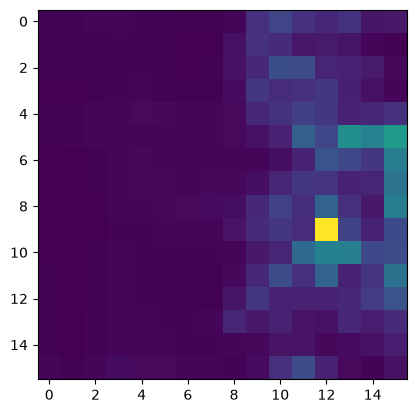

In [16]:
plt.imshow(agent.att_map[0].max(dim=0)[0].view(16,16))

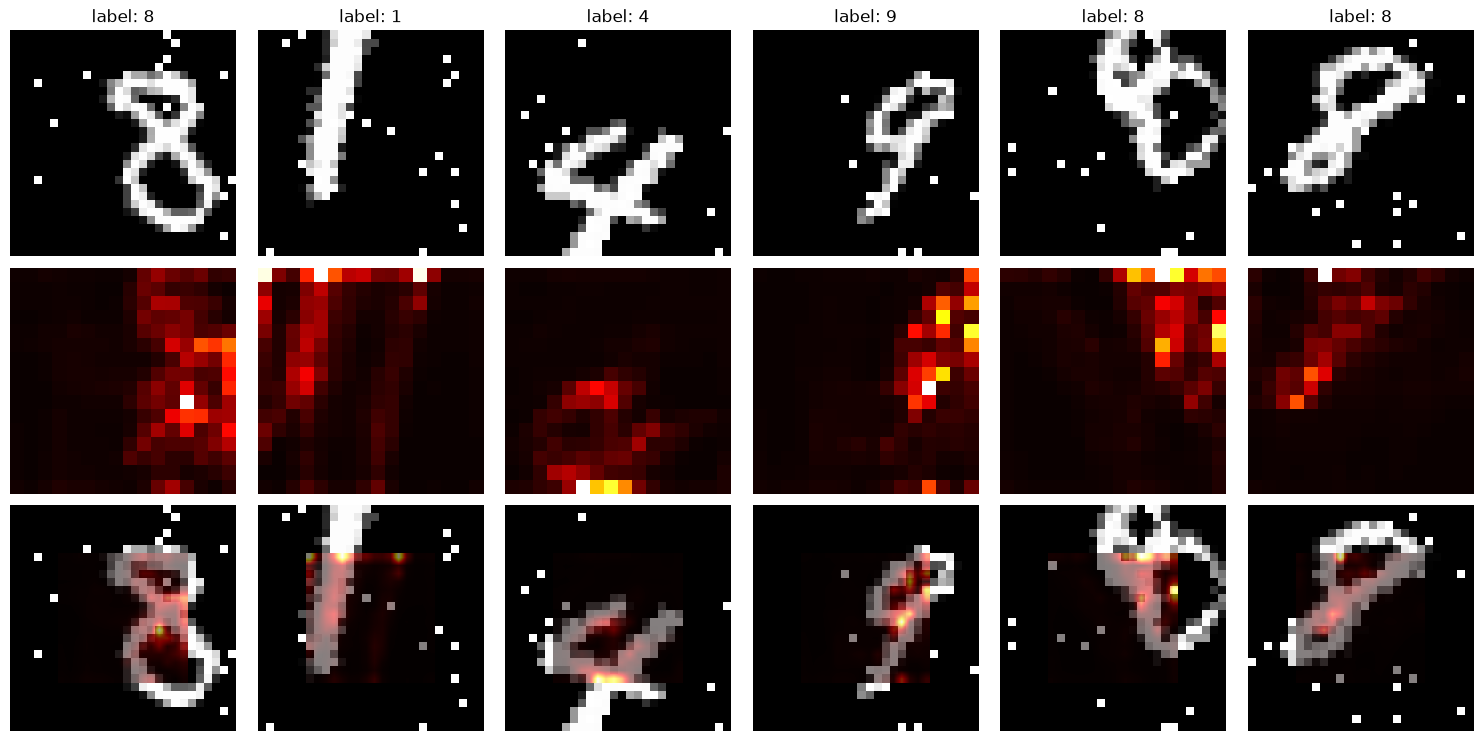

In [17]:
# 感受野对齐可视化
# 原理: 4 层 Conv(k=4) 累计感受野 13x13, 每个 16x16 att 格子 (i,j)
# 的感受野中心位于原图 (i+6, j+6), 16 个中心横跨输入的 [6, 21] 像素,
# 边缘一圈 6 像素完全没被 att 覆盖.
# 用 extent 把 att 放到它真正对应的坐标区间, bilinear 插值上采样,
# 半透明叠加在原图之上.
n = 6
fig, axes = plt.subplots(3, n, figsize=(2.5*n, 7.5))
for i in range(n):
    orig = xt2[i].squeeze().detach().numpy()
    att = agent.att_map[i].max(dim=0)[0].view(16, 16).detach().numpy()

    # 第 1 行: 原图
    axes[0, i].imshow(orig, cmap='gray')
    axes[0, i].set_title(f"label: {yt2[i].item()}")
    axes[0, i].axis('off')

    # 第 2 行: 原始画法 (16x16 直接填满 subplot, 与原图错位)
    axes[1, i].imshow(att, cmap='hot')
    axes[1, i].axis('off')

    # 第 3 行: 对齐叠加 (用 extent 把 att 放到 [5.5, 21.5] 这块区域)
    axes[2, i].imshow(orig, cmap='gray')
    axes[2, i].imshow(
        att, cmap='hot', alpha=0.5,
        extent=(5.5, 21.5, 21.5, 5.5),   # (left, right, bottom, top)
        interpolation='bilinear',
    )
    # 坐标锁回整张 28x28, 让未被 att 覆盖的边缘也保持可见
    axes[2, i].set_xlim(-0.5, 27.5)
    axes[2, i].set_ylim(27.5, -0.5)
    axes[2, i].axis('off')

plt.tight_layout()
plt.show()

In [18]:
class CNN(torch.nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(1,10,kernel_size=(4,4))
        self.conv2 = nn.Conv2d(10,16,kernel_size=(4,4))
        self.conv3 = nn.Conv2d(16,24,kernel_size=(4,4))
        self.conv4 = nn.Conv2d(24,32,kernel_size=(4,4))

        self.maxpool1 = nn.MaxPool2d(kernel_size=(2,2))

        self.conv5 = nn.Conv2d(32,64,kernel_size=(4,4))
        self.lin1 = nn.Linear(256,128)
        self.out = nn.Linear(128,10)

    def forward(self,x):
        x = self.conv1(x) 
        x = nn.functional.relu(x)
        x = self.conv2(x) 
        x = nn.functional.relu(x)

        x = self.maxpool1(x)

        x = self.conv3(x) 
        x = nn.functional.relu(x) 
        x = self.conv4(x) 
        x = nn.functional.relu(x)

        x = self.conv5(x) 
        x = nn.functional.relu(x)

        x = x.flatten(start_dim=1) 
        x = self.lin1(x) 
        x = nn.functional.relu(x)

        x = self.out(x) 
        x = nn.functional.log_softmax(x,dim=1) 
        return x
        



In [19]:
agent_CNN = CNN()
epochs = 10000
batch_size = 300
lr = 1e-3
opt = torch.optim.Adam(params=agent_CNN.parameters(),lr=lr)
lossfn = nn.NLLLoss()
losses = []
accuracy = []
for i in range(epochs):
    opt.zero_grad()
    batch_ids = np.random.randint(0, 60000, size=batch_size)
    xt = mnist_data.data[batch_ids].detach()
    xt = prepare_images(xt,rot=30).unsqueeze(dim=1)
    yt = mnist_data.targets[batch_ids].detach()
    pred = agent_CNN(xt)
    pred_labels = torch.argmax(pred,dim=1)

    acc_ = 100 * (pred_labels == yt).sum() / batch_size
    accuracy.append(acc_)
    correct = torch.zeros(batch_size,10)
    rows = torch.arange(batch_size).long()
    correct[rows,yt.detach().long()] = 1
    loss = lossfn(pred,yt)
    losses.append(loss.detach())
    loss.backward()
    opt.step()


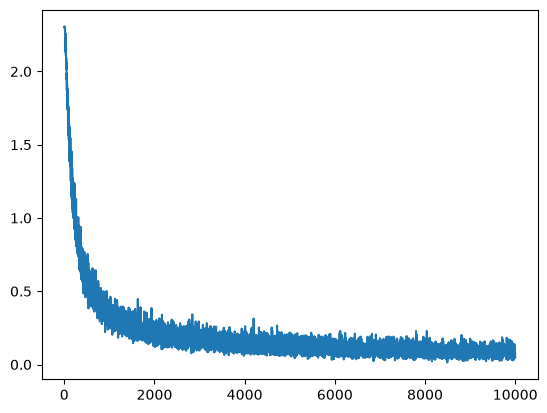

In [20]:
plt.plot(losses)


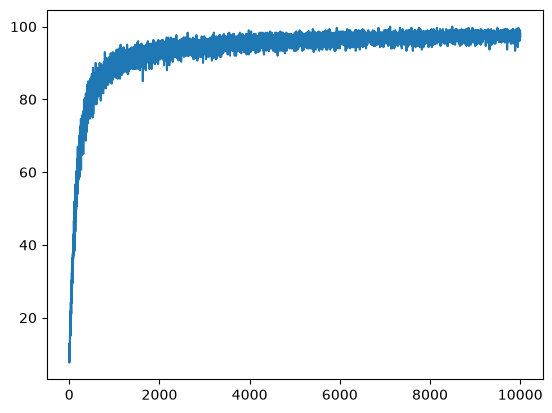

In [21]:
plt.plot(accuracy)


In [22]:
print(accuracy[-1])

tensor(98.)


In [23]:
acc2, xt2, yt2 = test_acc(agent_CNN)

In [24]:
print(acc2)

tensor(0.9820)


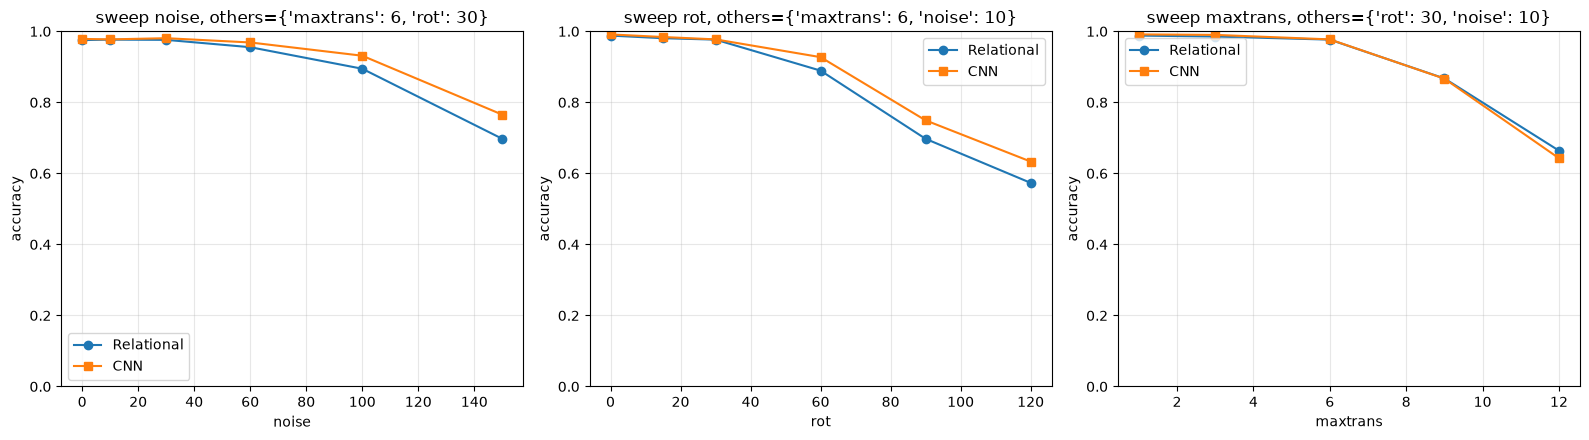

In [25]:
# 对比 RelationalModule 与 CNN 在不同变换强度下的鲁棒性
# 结论应能复现书里的观点: 变换越猛, relational 比 CNN 掉得慢

@torch.no_grad()
def eval_acc(model, xt, yt):
    model.eval()
    return (torch.argmax(model(xt), dim=1) == yt).float().mean().item()

def make_batch(maxtrans, rot, noise, batch_size=500, seed=0):
    # 用同一个 seed, 保证两个模型看到完全相同的图
    np.random.seed(seed)
    ids = np.random.randint(0, 10000, size=batch_size)
    xt = mnist_test.data[ids].detach()
    xt = prepare_images(xt, maxtrans=maxtrans, rot=rot, noise=noise).unsqueeze(1)
    yt = mnist_test.targets[ids].detach()
    return xt, yt

def sweep(param_name, levels, base, n_trials=3):
    rel, cnn = [], []
    for lv in levels:
        cfg = {**base, param_name: lv}
        r, c = [], []
        for s in range(n_trials):
            xt, yt = make_batch(seed=s, **cfg)
            r.append(eval_acc(agent, xt, yt))
            c.append(eval_acc(agent_CNN, xt, yt))
        rel.append(np.mean(r))
        cnn.append(np.mean(c))
    return np.array(rel), np.array(cnn)

# 训练时的默认: maxtrans=6, rot=30, noise=20 (prepare_images 默认)
base = dict(maxtrans=6, rot=30, noise=10)
noise_levels = [0, 10, 30, 60, 100, 150]
rot_levels   = [0, 15, 30, 60, 90, 120]
trans_levels = [1, 3, 6, 9, 12]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, (name, lvs) in zip(
    axes, [('noise', noise_levels), ('rot', rot_levels), ('maxtrans', trans_levels)]
):
    rel, cnn = sweep(name, lvs, base)
    ax.plot(lvs, rel, 'o-', label='Relational')
    ax.plot(lvs, cnn, 's-', label='CNN')
    ax.set_xlabel(name)
    ax.set_ylabel('accuracy')
    ax.set_ylim(0, 1)
    ax.grid(alpha=0.3)
    ax.legend()
    fixed = {k: v for k, v in base.items() if k != name}
    ax.set_title(f'sweep {name}, others={fixed}')
plt.tight_layout()
plt.show()

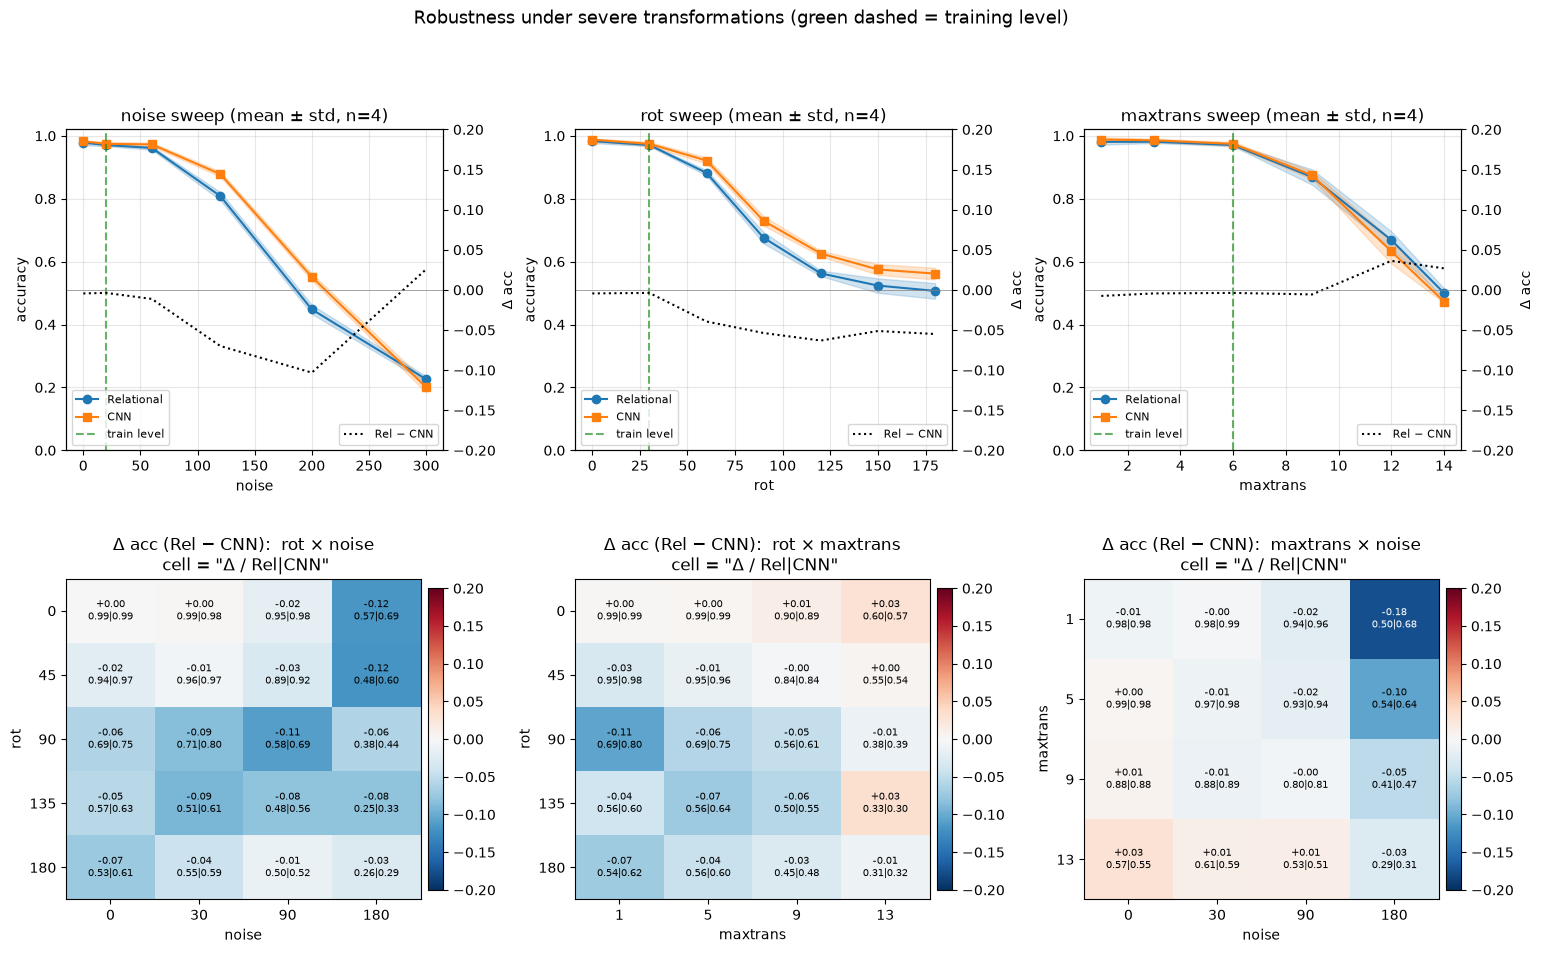

In [26]:
# 更严苛的鲁棒性对比: 1D sweep (mean±std) + 2D delta 热图
# 依赖: agent (RelationalModule), agent_CNN (CNN), make_batch(), eval_acc()

def sweep_1d_stats(name, levels, base, n_trials=4, bs=400):
    """返回 (rel_mu, rel_sd, cnn_mu, cnn_sd), 每级 n_trials 次不同 seed 平均"""
    rm, rs, cm, cs = [], [], [], []
    for lv in levels:
        cfg = {**base, name: lv}
        r, c = [], []
        for s in range(n_trials):
            xt, yt = make_batch(seed=s, batch_size=bs, **cfg)
            r.append(eval_acc(agent, xt, yt))
            c.append(eval_acc(agent_CNN, xt, yt))
        rm.append(np.mean(r)); rs.append(np.std(r))
        cm.append(np.mean(c)); cs.append(np.std(c))
    return tuple(np.array(x) for x in (rm, rs, cm, cs))

def sweep_2d(pa, la, pb, lb, base, n_trials=2, bs=300):
    Ra = np.zeros((len(la), len(lb))); Ca = np.zeros_like(Ra)
    for i, va in enumerate(la):
        for j, vb in enumerate(lb):
            cfg = {**base, pa: va, pb: vb}
            r, c = [], []
            for s in range(n_trials):
                xt, yt = make_batch(seed=s, batch_size=bs, **cfg)
                r.append(eval_acc(agent, xt, yt))
                c.append(eval_acc(agent_CNN, xt, yt))
            Ra[i, j] = np.mean(r); Ca[i, j] = np.mean(c)
    return Ra, Ca

# 训练分布 (作为参考锚点)
base_train = dict(maxtrans=6, rot=30, noise=20)

# 更严苛的 1D 范围
noise_lv = [0, 20, 60, 120, 200, 300]
rot_lv   = [0, 30, 60, 90, 120, 150, 180]
trans_lv = [1, 3, 6, 9, 12, 14]

fig = plt.figure(figsize=(18, 10))
gs = fig.add_gridspec(2, 3, hspace=0.4, wspace=0.35)

# 顶行: 三条 1D sweep, 带方差阴影 + Δ 双 y 轴
for k, (name, lvs) in enumerate([('noise', noise_lv), ('rot', rot_lv), ('maxtrans', trans_lv)]):
    ax = fig.add_subplot(gs[0, k])
    rm, rs, cm, cs = sweep_1d_stats(name, lvs, base_train)
    ax.plot(lvs, rm, 'o-', color='C0', label='Relational')
    ax.fill_between(lvs, rm - rs, rm + rs, color='C0', alpha=0.2)
    ax.plot(lvs, cm, 's-', color='C1', label='CNN')
    ax.fill_between(lvs, cm - cs, cm + cs, color='C1', alpha=0.2)
    ax.axvline(base_train[name], color='green', linestyle='--', alpha=0.6, label='train level')
    ax.set_xlabel(name); ax.set_ylabel('accuracy'); ax.set_ylim(0, 1.02)
    ax.grid(alpha=0.3); ax.set_title(f'{name} sweep (mean ± std, n=4)')
    ax.legend(loc='lower left', fontsize=8)
    # Δ 曲线在 twin 轴上
    ax2 = ax.twinx()
    ax2.plot(lvs, rm - cm, ':', color='k', linewidth=1.5, label='Rel − CNN')
    ax2.axhline(0, color='gray', linewidth=0.5)
    ax2.set_ylim(-0.2, 0.2); ax2.set_ylabel('Δ acc', color='k')
    ax2.legend(loc='lower right', fontsize=8)

# 底行: 三个 2D delta 热图
noise_hm = [0, 30, 90, 180]
rot_hm   = [0, 45, 90, 135, 180]
trans_hm = [1, 5, 9, 13]
pairs = [
    ('rot',      rot_hm,   'noise',    noise_hm),
    ('rot',      rot_hm,   'maxtrans', trans_hm),
    ('maxtrans', trans_hm, 'noise',    noise_hm),
]
for k, (pa, la, pb, lb) in enumerate(pairs):
    ax = fig.add_subplot(gs[1, k])
    Ra, Ca = sweep_2d(pa, la, pb, lb, base_train, n_trials=2)
    delta = Ra - Ca
    im = ax.imshow(delta, cmap='RdBu_r', vmin=-0.2, vmax=0.2, aspect='auto')
    for i in range(len(la)):
        for j in range(len(lb)):
            v = delta[i, j]
            ax.text(j, i, f'{v:+.02f}\n{Ra[i,j]:.02f}|{Ca[i,j]:.02f}',
                    ha='center', va='center',
                    color='white' if abs(v) > 0.12 else 'black', fontsize=7)
    ax.set_xticks(range(len(lb))); ax.set_xticklabels(lb)
    ax.set_yticks(range(len(la))); ax.set_yticklabels(la)
    ax.set_xlabel(pb); ax.set_ylabel(pa)
    ax.set_title(f'Δ acc (Rel − CNN):  {pa} × {pb}\n cell = "Δ / Rel|CNN"')
    plt.colorbar(im, ax=ax, fraction=0.04, pad=0.02)

plt.suptitle('Robustness under severe transformations (green dashed = training level)',
             fontsize=13, y=1.00)
plt.show()

In [27]:
from einops import rearrange

In [28]:
x = torch.randn(4, 7, 3, 5)
rearrange(x,"batch h w c -> batch c h w").shape

torch.Size([4, 5, 7, 3])

In [29]:
x = torch.rand(3, 49, 5)
rearrange(x,"batch (h w) c -> batch h w c", h=7).shape

torch.Size([3, 7, 7, 5])

In [30]:
class MultiHeadRelationalModule(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1_ch = 16
        self.conv2_ch = 20
        self.conv3_ch = 24
        self.conv4_ch = 30
        self.H = 28
        self.W = 28
        self.node_size = 64
        self.lin_hid = 100
        self.out_dim = 5
        self.ch_in = 3
        self.sp_coord_dim = 2
        self.N = int(7**2)
        self.n_heads = 3

        self.conv1 = nn.Conv2d(self.ch_in,self.conv1_ch,kernel_size=(1,1),padding=0)
        self.conv2 = nn.Conv2d(self.conv1_ch,self.conv2_ch,kernel_size=(1,1),padding=0)

        self.proj_shape = (self.conv2_ch+self.sp_coord_dim,self.n_heads * self.node_size)

        self.k_proj = nn.Linear(*self.proj_shape)
        self.q_proj = nn.Linear(*self.proj_shape)
        self.v_proj = nn.Linear(*self.proj_shape)

        self.k_lin = nn.Linear(self.node_size,self.N)
        self.q_lin = nn.Linear(self.node_size,self.N)
        self.a_lin = nn.Linear(self.N,self.N)

        self.node_shape = (self.n_heads,self.N,self.node_size)
        self.k_norm = nn.LayerNorm(self.node_shape,elementwise_affine=True)
        self.q_norm = nn.LayerNorm(self.node_shape,elementwise_affine=True)
        self.v_norm = nn.LayerNorm(self.node_shape,elementwise_affine=True)

        self.linear1 = nn.Linear(self.n_heads * self.node_size, self.node_size)
        self.norm1 = nn.LayerNorm([self.N,self.node_size],elementwise_affine=False)
        self.linear2 = nn.Linear(self.node_size, self.out_dim)

    def forward(self,x):
        B, Cin, H, W = x.shape

        x = self.conv1(x)
        x = torch.relu(x)
        x = self.conv2(x)
        x = torch.relu(x)

        # Saves a copy of the post-convolved input for later visualization
        with torch.no_grad():
            self.conv_map = x.clone() 

        _, _, cH, cW = x.shape

        xcoords = torch.arange(cW).repeat(cH,1).float() / cW
        ycoords = torch.arange(cH).repeat(cW,1).transpose(1,0).float() / cH

        spatial_coords = torch.stack([xcoords, ycoords],dim=0)
        spatial_coords = spatial_coords.unsqueeze(dim=0)
        spatial_coords = spatial_coords.repeat(B, 1, 1, 1)

        x = torch.cat([x,spatial_coords],dim=1)

        x = x.permute(0,2,3,1)
        x = x.flatten(1,2)

        K = rearrange(self.k_proj(x), "b n (head d) -> b head n d",head=self.n_heads)
        K = self.k_norm(K)

        Q = rearrange(self.q_proj(x), "b n (head d) -> b head n d",head=self.n_heads)
        Q = self.q_norm(Q)

        V = rearrange(self.v_proj(x), "b n (head d) -> b head n d",head=self.n_heads)
        V = self.v_norm(V)

        A = torch.nn.functional.elu(self.k_lin(K)+self.q_lin(Q))
        A = self.a_lin(A)
        A = torch.nn.functional.softmax(A, dim=3) # d

        # Saves a copy of the attention weights for later visualization
        with torch.no_grad():
            self.att_map = A.clone()

        E = torch.einsum('bhfc,bhcd->bhfd',A,V)
        E = rearrange(E, 'B head n d -> B n (head d)')
        E = self.linear1(E)
        E = torch.relu(E)
        E = self.norm1(E)
        E = E.max(dim=1)[0]

        y = self.linear2(E)
        y = torch.nn.functional.elu(y)
        return y


In [31]:
import gymnasium as gym
from minigrid.wrappers import ImgObsWrapper
from skimage.transform import resize

def prepare_state(x:np.array):
    # NumPy 图片通常是 H × W × C
    # Normalizes the state tensor and converts to PyTorch tensor
    ns = torch.from_numpy(x).float().permute(2,1,0).unsqueeze(dim=0) 
    maxv = ns.flatten().max()
    ns /= maxv
    return ns


def get_minibatch(replay,size):
    batch_ids = np.random.randint(0, len(replay), size)
    batch = [replay[id] for id in batch_ids]

    state_batch = torch.cat([exp[0] for exp in batch])
    action_batch = torch.Tensor([exp[1] for exp in batch]).long()
    reward_batch = torch.Tensor([exp[2] for exp in batch])
    state2_batch = torch.cat([exp[3] for exp in batch])
    done_batch = torch.Tensor([exp[4] for exp in batch])
    return state_batch,action_batch,reward_batch,state2_batch, done_batch


def get_qtarget_ddqn(qvals,r,df,done):
    # Calculates the target Q value
    # df: gamma
    targets = r + (1-done) * df * qvals
    return targets





In [32]:
# Def loss function

def lossfn(pred, targets, actions):
    loss = torch.mean(torch.pow(targets.detach()-pred.gather(dim=1,index=actions.unsqueeze(dim=1)),2))
    return loss

def update_replay(replay,exp,replay_size):
    r = exp[2] # get the reward of this exp
    N = 1
    if r > 0: # if result is positive , multiply to prioritize
        N = 50
    for i in range(N):
        replay.append(exp)
    return replay

# Maps the action outputs of 
# the DQN to a subset of actions in the environment
action_map = {
    0:0,
    1:1,
    2:2,
    3:3,
    4:5 # <- here
}

In [ ]:
from collections import deque

# gym.make() 负责创建环境，ImgObsWrapper 负责修改环境的 observation 形式，
# 让它直接返回图像数据，方便 CNN/DQN 使用。
env = ImgObsWrapper(gym.make('MiniGrid-DoorKey-5x5-v0'))
state = prepare_state(env.reset()[0])
GWagent = MultiHeadRelationalModule()
Tnet = MultiHeadRelationalModule()

maxsteps = 400
env.unwrapped.max_steps = maxsteps

epochs = 50000
replay_size = 5000
lr = 0.0005
gamma = 0.99

replay = deque(maxlen=replay_size)

opt = torch.optim.Adam(params=GWagent.parameters(),lr=lr)

eps = 0.5
update_freq = 100

for i in range(epochs):
    done = False
    pred = GWagent(state) # 5 action value
    action = int(torch.argmax(pred))
    if np.random.randn() < eps:
        action = int(torch.randint(0,5,size=(1,)).squeeze())
    action_d = action_map[action]

    state2, reward, terminated, truncated, info = env.step(action_d)

    state2 = prepare_state(state2)
    reward = -0.01 if reward == 0 else reward
    if terminated or truncated: done = True
    exp = (state, action, reward, state2, done ) # action or action_d?

    replay = update_replay(replay,exp,replay_size)

    if done:
        state = prepare_state(env.reset()[0])
    else:
        state = state2

    if len(replay) > batch_size:

        opt.zero_grad()

        state_batch, action_batch, reward_batch, state2_batch, done_batch = \
            get_minibatch(replay, batch_size)

        q_pred = GWagent(state_batch)
        astar = torch.argmax(q_pred,dim=1)
        qs = Tnet(state2_batch).gather(dim=1,index=astar.unsqueeze(dim=1)).squeeze()

        targets = get_qtarget_ddqn(qs.detach(),reward_batch,gamma,done_batch)

        loss = lossfn(q_pred,targets.detach(),action_batch)

        loss.backward()

        # Clips the gradients to prevent overly large gradients
        torch.nn.utils.clip_grad_norm_(GWagent.parameters(), max_norm=1.0)
        opt.step()

        if i % update_freq == 0:
            Tnet.load_state_dict(GWagent.state_dict)
    

In [34]:
print(type(env))
print(type(env.env))
print(type(env.env.env))
print(type(env.unwrapped))

<class 'minigrid.wrappers.ImgObsWrapper'>
<class 'gymnasium.wrappers.common.OrderEnforcing'>
<class 'gymnasium.wrappers.common.PassiveEnvChecker'>
<class 'minigrid.envs.doorkey.DoorKeyEnv'>
